In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.signal import convolve2d
from scipy.optimize import curve_fit

In [3]:
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'lines.linewidth': 2})

def findMoment(arr,order,shift=0):
    # Shift i to i - 50
    shifted_indices = np.arange(len(arr)) - (len(arr)/2) - shift
    
    zero = np.average(arr[0:10])

    # return np.sum(shifted_indices**order * (arr-np.min(arr))) / np.sum(arr-np.min(arr))
    # return np.sum(shifted_indices**order * (np.abs(arr-zero)) / np.sum(np.abs(arr-zero)))
    return np.sum(shifted_indices**order * (arr-zero) / np.sum(np.abs(arr-zero)))

def gaussian_2d(coor, x0, y0, sigma_x, sigma_y, amplitude, offset):
    """2D Gaussian function."""
    x = coor[0]
    y = coor[1]
    return offset + amplitude * np.exp(
        -(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2))
    )

## Correlation Rnd Diagonal Hopping Interaction

100\*100\*400, dx=10 nm, J=5 A/m, 1

In [48]:
file_name = "../data/250211/250211_1_"
x_l = np.loadtxt(file_name+'pcoor_scanx.csv',skiprows=1)
y_l = np.loadtxt(file_name+'pcoor_scany.csv',skiprows=1)
t_l = np.loadtxt(file_name+'pcoor_scanz.csv',skiprows=1)
raw = np.loadtxt(file_name+'pcoor_data.csv',skiprows=1,delimiter=',')
pcoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')
raw = np.loadtxt(file_name+'ncoor_data.csv',skiprows=1,delimiter=',')
ncoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')
raw = np.loadtxt(file_name+'scoor_data.csv',skiprows=1,delimiter=',')
scoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')

mid_lattice = int(len(x_l)/2)

780415.76


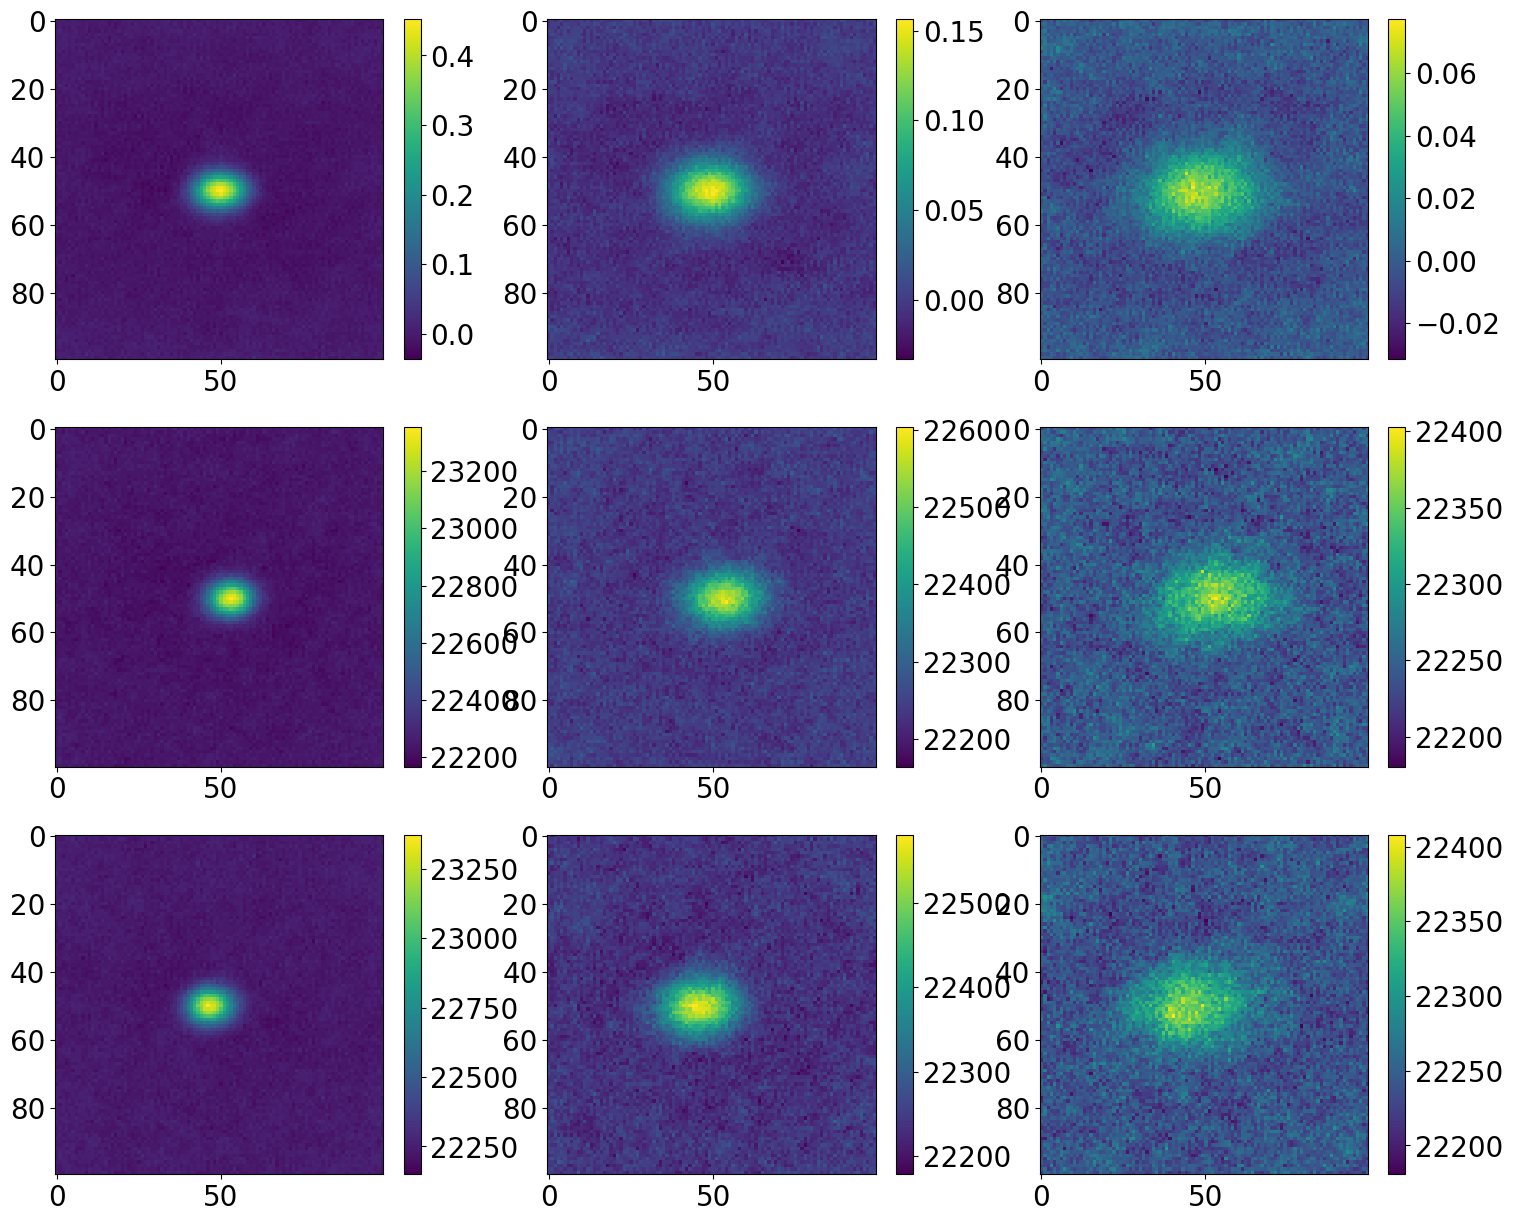

In [71]:
t1 = 20
t2 = 50
t3 = 100

plt.figure(figsize=(18,15))
plt.subplot(3,3,1)
scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r/np.max(scoor[:,:,10]),aspect='auto')
plt.colorbar()
plt.subplot(3,3,2)
scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r/np.max(scoor[:,:,10]),aspect='auto')
plt.colorbar()
plt.subplot(3,3,3)
scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r/np.max(scoor[:,:,10]),aspect='auto')
plt.colorbar()
plt.subplot(3,3,4)
pcoor_r = np.roll(pcoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,5)
pcoor_r = np.roll(pcoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,6)
pcoor_r = np.roll(pcoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,7)
ncoor_r = np.roll(ncoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,8)
ncoor_r = np.roll(ncoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,9)
ncoor_r = np.roll(ncoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()

print(np.max(scoor[:,:,0]))

### Fit Gaussian

In [44]:
params_l = []
# for t in range(int(scoor.shape[-1]/2)):
for t in range(100):
    scoor_t = np.roll(scoor[:,:,t],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
    # Get the coordinates of the pixels
    x = np.arange(0, scoor_t.shape[1])
    y = np.arange(0, scoor_t.shape[0])
    x, y = np.meshgrid(x, y)

    # Flatten the arrays for fitting
    x = x.ravel()
    y = y.ravel()
    z = scoor_t.ravel()

    # Initial guess for the parameters
    initial_guess = (scoor_t.shape[1] / 2, scoor_t.shape[0] / 2, 1, 1, np.max(scoor_t), np.min(scoor_t))
    
    # Fit the data
    params, _ = curve_fit(gaussian_2d, (x, y), z, p0=initial_guess)

    # Extract the parameters
    x0, y0, sigma_x, sigma_y, amplitude, offset = params
    params_l.append(params)

params_l = np.array(params_l)
params_l.shape

/Users/frankzhang/anaconda3/envs/ece396/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(100, 6)

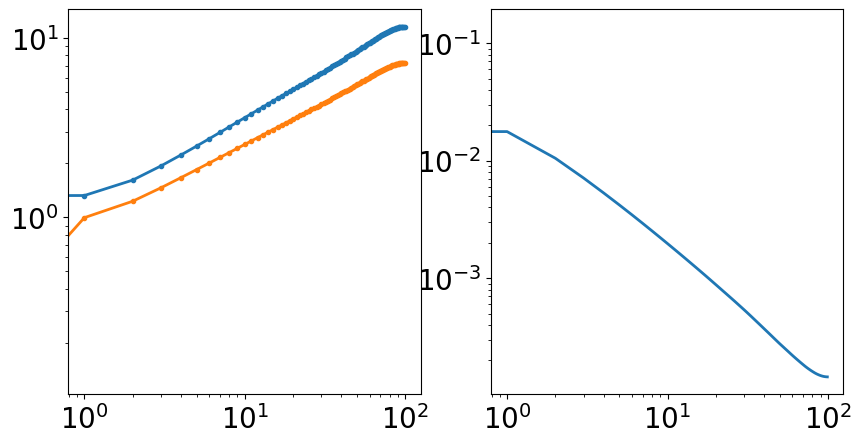

In [45]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(params_l[:,2],'.-')
plt.plot(params_l[:,3],'.-')
# plt.ylim(1e0,1e1)
plt.xscale('log')
plt.yscale('log')
plt.subplot(1,2,2)
plt.plot(params_l[:,4]/(200*100*100))
plt.xscale('log')
plt.yscale('log')

In [8]:
slope_start = 10
slope_end = 100

tfit_l = np.arange(slope_start,slope_end,dtype=int)
m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,2]), 1)
print("var exponents", m, "base", b)
m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,3]), 1)
print("var exponents", m, "base", b)
m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,4]), 1)
print("var exponents", m)

var exponents 0.5108164716389978 base 0.1352910370089552
var exponents 0.4893798458577175 base -0.20005824213141365
var exponents -1.215053944562475


### Scan J=2-8 A/m
100\*100\*300

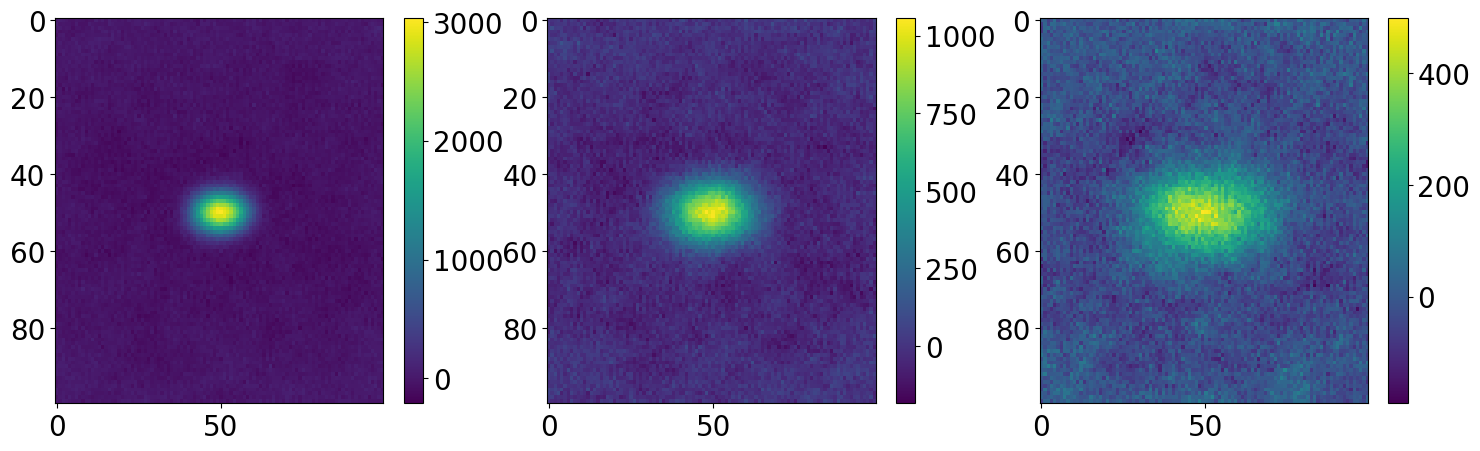

In [116]:
file_name = "../data/250211/250211_%d_"%(16)
x_l = np.loadtxt(file_name+'scoor_scanx.csv',skiprows=1)
y_l = np.loadtxt(file_name+'scoor_scany.csv',skiprows=1)
t_l = np.loadtxt(file_name+'scoor_scanz.csv',skiprows=1)
raw = np.loadtxt(file_name+'scoor_data.csv',skiprows=1,delimiter=',')
scoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')

t1 = 20
t2 = 50
t3 = 100

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r,aspect='auto')
plt.colorbar()
plt.subplot(1,3,2)
scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r,aspect='auto')
plt.colorbar()
plt.subplot(1,3,3)
scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.imshow(scoor_r,aspect='auto')
plt.colorbar()

/Users/frankzhang/anaconda3/envs/ece396/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


var exponents 0.5232336649270707 base 0.13082054430369713
var exponents 0.45894123537391573 base -0.10211839462893302
var exponents -1.174091670095705


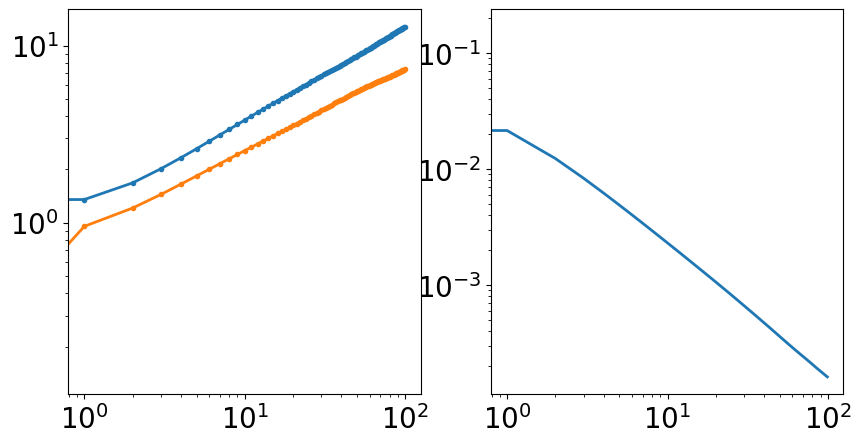

In [117]:
params_l = []
# for t in range(int(scoor.shape[-1]/2)):
for t in range(100):
    scoor_t = np.roll(scoor[:,:,t],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
    # Get the coordinates of the pixels
    x = np.arange(0, scoor_t.shape[1])
    y = np.arange(0, scoor_t.shape[0])
    x, y = np.meshgrid(x, y)

    # Flatten the arrays for fitting
    x = x.ravel()
    y = y.ravel()
    z = scoor_t.ravel()

    # Initial guess for the parameters
    initial_guess = (scoor_t.shape[1] / 2, scoor_t.shape[0] / 2, 1, 1, np.max(scoor_t), np.min(scoor_t))
    
    # Fit the data
    params, _ = curve_fit(gaussian_2d, (x, y), z, p0=initial_guess)

    # Extract the parameters
    x0, y0, sigma_x, sigma_y, amplitude, offset = params
    params_l.append(params)

params_l = np.array(params_l)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(params_l[:,2],'.-')
plt.plot(params_l[:,3],'.-')
# plt.ylim(1e0,1e1)
plt.xscale('log')
plt.yscale('log')
plt.subplot(1,2,2)
plt.plot(params_l[:,4]/(300*100*100))
plt.xscale('log')
plt.yscale('log')

slope_start = 10
slope_end = 100

tfit_l = np.arange(slope_start,slope_end,dtype=int)
m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,2]), 1)
print("var exponents", m, "base", b)
m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,3]), 1)
print("var exponents", m, "base", b)
m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,4]), 1)
print("var exponents", m)

In [112]:
Je_l = [2,3,4,5,6,7,8]
mx_l = []
bx_l = []
my_l = []
by_l = []
ma_l = []
ba_l = []
bd_l = []

for i in range(len(Je_l)):
    file_name = "../data/250211/250211_%d_"%(12+i)
    x_l = np.loadtxt(file_name+'scoor_scanx.csv',skiprows=1)
    y_l = np.loadtxt(file_name+'scoor_scany.csv',skiprows=1)
    t_l = np.loadtxt(file_name+'scoor_scanz.csv',skiprows=1)
    raw = np.loadtxt(file_name+'scoor_data.csv',skiprows=1,delimiter=',')
    scoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')

    params_l = []
    # for t in range(int(scoor.shape[-1]/2)):
    for t in range(100):
        scoor_t = np.roll(scoor[:,:,t],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
        # Get the coordinates of the pixels
        x = np.arange(0, scoor_t.shape[1])
        y = np.arange(0, scoor_t.shape[0])
        x, y = np.meshgrid(x, y)

        # Flatten the arrays for fitting
        x = x.ravel()
        y = y.ravel()
        z = scoor_t.ravel()

        # Initial guess for the parameters
        initial_guess = (scoor_t.shape[1] / 2, scoor_t.shape[0] / 2, 1, 1, np.max(scoor_t), np.min(scoor_t))
        
        # Fit the data
        params, _ = curve_fit(gaussian_2d, (x, y), z, p0=initial_guess)

        # Extract the parameters
        x0, y0, sigma_x, sigma_y, amplitude, offset = params
        params_l.append(params)

    params_l = np.array(params_l)

    params_l = []
    # for t in range(int(scoor.shape[-1]/2)):
    for t in range(100):
        scoor_t = np.roll(scoor[:,:,t],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
        # Get the coordinates of the pixels
        x = np.arange(0, scoor_t.shape[1])
        y = np.arange(0, scoor_t.shape[0])
        x, y = np.meshgrid(x, y)

        # Flatten the arrays for fitting
        x = x.ravel()
        y = y.ravel()
        z = scoor_t.ravel()

        # Initial guess for the parameters
        initial_guess = (scoor_t.shape[1] / 2, scoor_t.shape[0] / 2, 1, 1, np.max(scoor_t), np.min(scoor_t))
        
        # Fit the data
        params, _ = curve_fit(gaussian_2d, (x, y), z, p0=initial_guess)

        # Extract the parameters
        x0, y0, sigma_x, sigma_y, amplitude, offset = params
        params_l.append(params)


    params_l = np.array(params_l)
    slope_start = 50
    slope_end = 100

    tfit_l = np.arange(slope_start,slope_end,dtype=int)
    m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,2]), 1)
    mx_l.append(m)
    bx_l.append(b)
    m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,3]), 1)
    my_l.append(m)
    by_l.append(b)
    m, b = np.polyfit(np.log(tfit_l), np.log(params_l[slope_start:slope_end,4]/(300*100*100)), 1)
    ma_l.append(m)
    ba_l.append(b)

    bd_l.append(np.log(params_l[slope_end-1,2])-np.log(params_l[slope_end-1,3]))


Je_l = np.array(Je_l)
mx_l = np.array(mx_l)
bx_l = np.array(bx_l)
my_l = np.array(my_l)
by_l = np.array(by_l)
ma_l = np.array(ma_l)
ba_l = np.array(ba_l)
bd_l = np.array(bd_l)

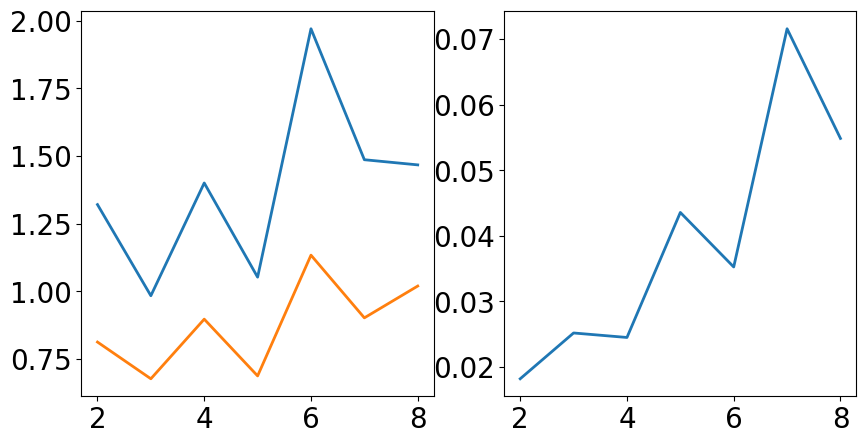

In [119]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
# plt.plot(Je_l, np.exp(bx_l))
plt.plot(Je_l, np.exp(by_l+bd_l))
plt.plot(Je_l, np.exp(by_l))
plt.subplot(1,2,2)
plt.plot(Je_l, np.exp(ba_l))